<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter10/10_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#어텐션 매커니즘과 트랜스포터
대규모 언어 모델 기초 다지기

## 순환 신경망을 사용한 인코더 디코더 네트워크

9장에서 공부한 순환 신경망은 텍스트와 같은 시퀀스 데이터를 효과적으로 처리할 수 있지만 시퀀스가 길어질수록 전에 처리한 데이터를 기억하기 어려워지고 품질도 떨어짐.

이를 위해 LSTM이나 GRU셀같은 구조가 개발되었지만 부족함.

이러한 문제는 기계번역 어플리케이션에서도 두드러졌는데 기계번역에서 사용되는 신경망 구조는 전형적으로 시퀀스-투-시퀀스 구조를 가지고 있음

인코더 신경망은 입력된 문장을 단어(토큰) 단위로 하나씩 처리하면서 전체 정보를 하나의 은닉 상태에 압축.

디코더 신경망이 이 은닉 상태를 받아 한 단어씩 번역된 문장 생성.

이런 구조는 번역할 문장이 길어질수록 초기에 입력된 내용을 기억하기 어려워짐.

또한 입려그 출력 모두 한 토큰씩 받고 생성하므로 속도도 느림.

이처럼 디코더는 이전에 생성한 토큰을 참고하며 다음 토큰을 생성하는데 이를 자귀회귀 모델이라 함.

어텐션 매커니즘이 등장하면서 성능 개선
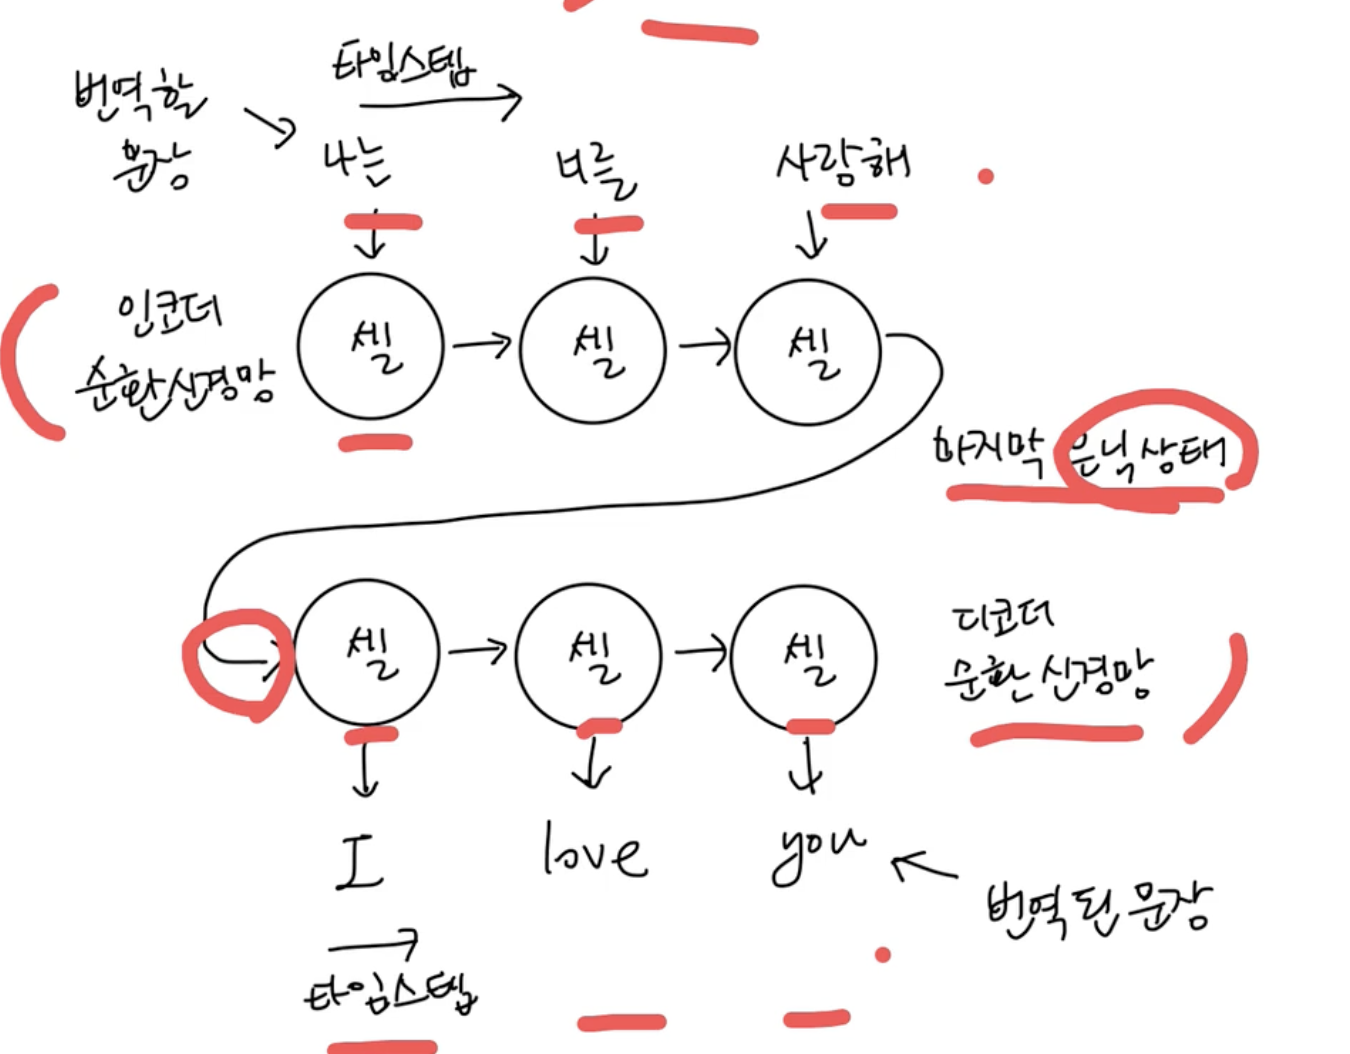

# 어텐션 매커니즘

인코더의 모든 타임스텝에서 계산된 은닉 상태를 활용한다.

디코더가 인코더의 은닉 상태를 활용하는 방식은 가중치를 곱하는 형태로 이루어진다.

디코더는 인코더의 모든 타임스텝에서 생성된 은닉 상태를 동일하게 참고하는 것이 아니라, 각 은닉상태마다 가중치를 다르게 적용해 더 중요한 정보를 강조한다.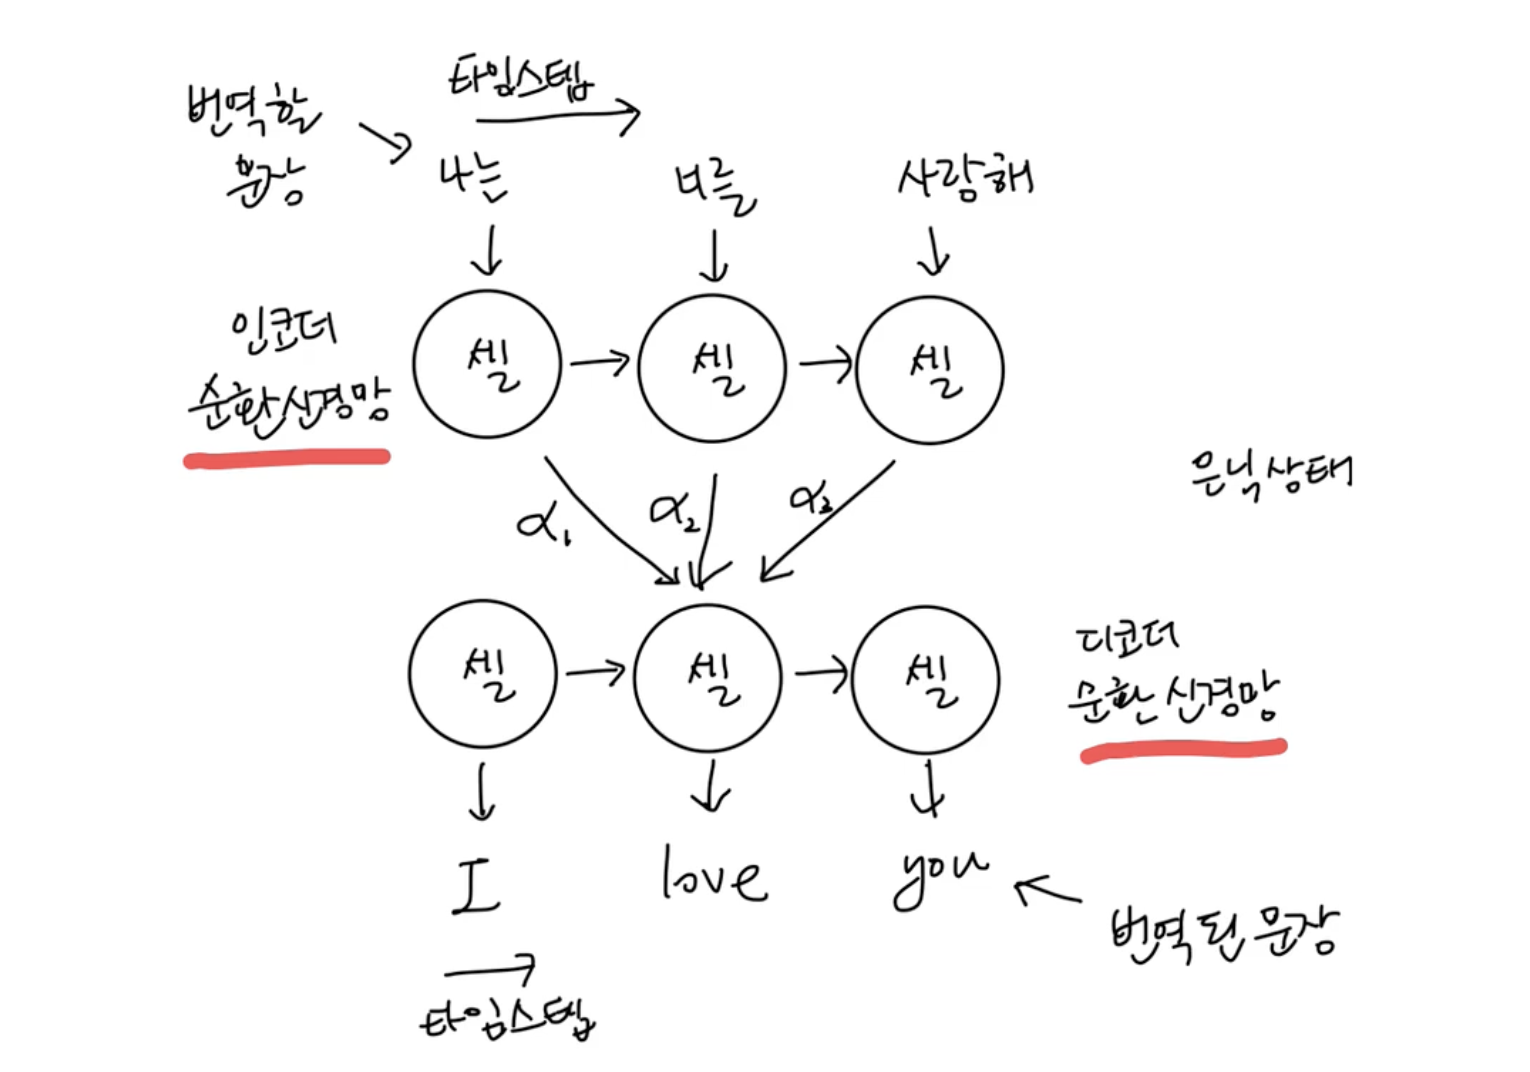

어텐션 매커니즘의 장단점.

긴 텍스트를 처리할 떄 정보 손실을 줄이는데 매우 효과적

하지만 모든 타임스텝에서 생성된 은닉 상태를 저장해서 어텐션 가중치를 계산하기에 연산량 증가.

따라서 인코더가 처리할 수 있는 타임스텝의 최대 개수를 정해야한다.

또한 여전히 한토큰씩 처리해하는 한계가 있다.

## 트랜스포머
어텐션 매커니즘 효과를 극대화.

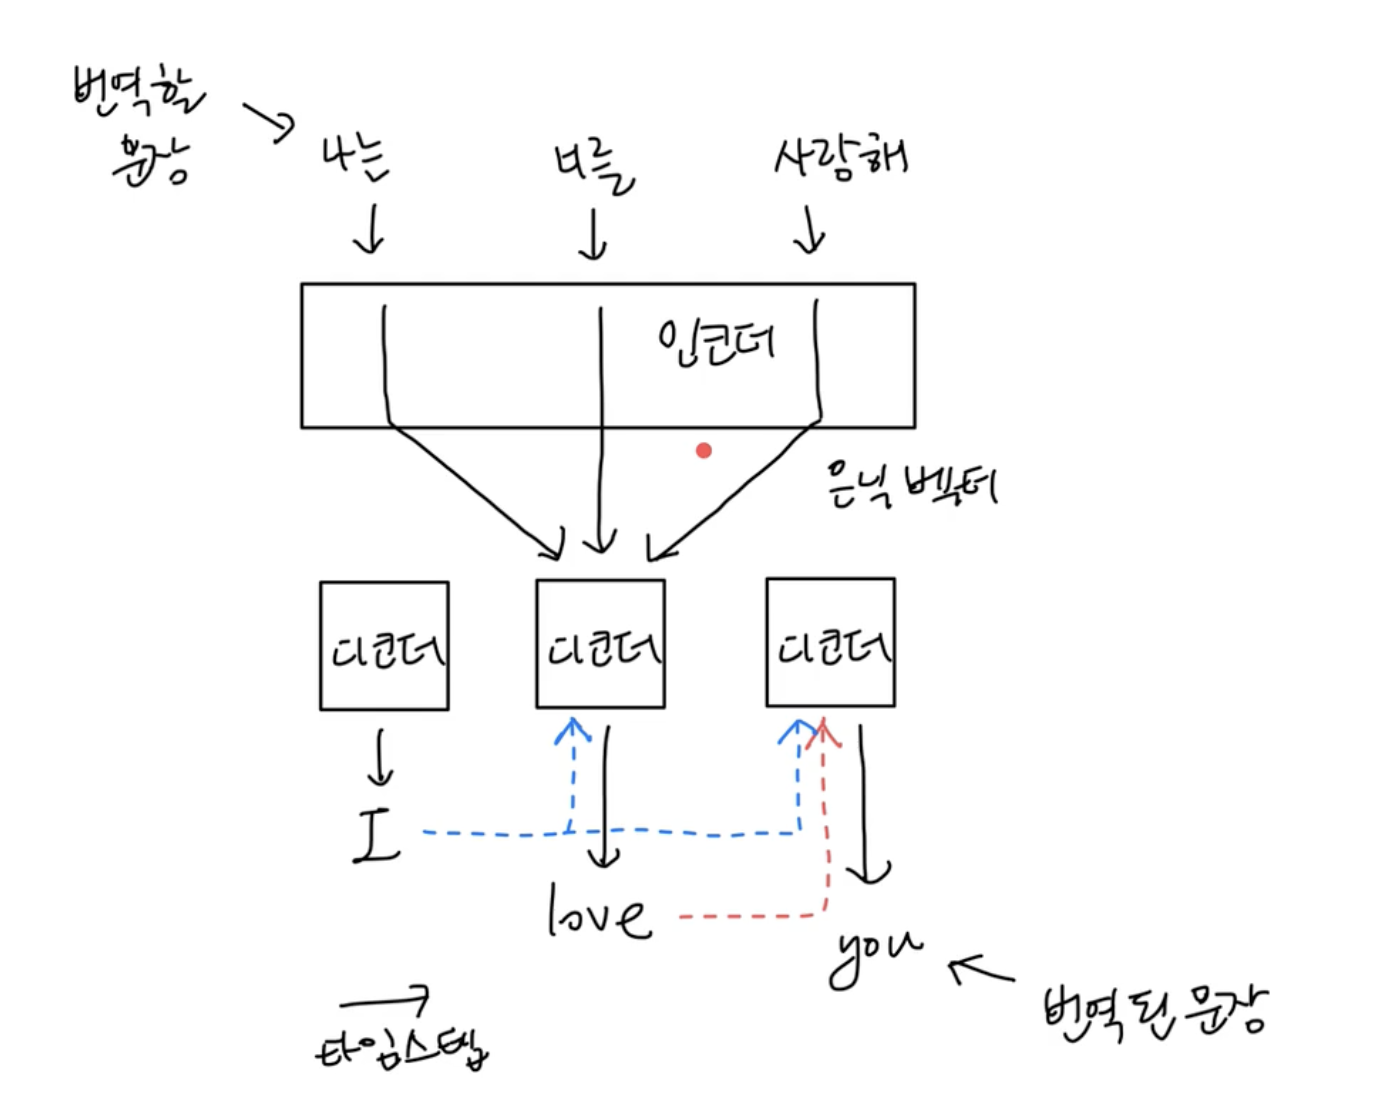

트랜스포머의 인코더는 입력된 텍스트를 한 번에 모두 처리한다. 기존의 순환 신경망과 달리, 타입스텝 개념이 필요하지 않다. 디코더는 인코더에서 전달 받은 은닉 벡터를 활요해 긱 타임스텝에서 출력할 토크을 생성한다. 디코더는 기존처럼 이전에 생성된 토큰을 참고하면서 새로운 토큰을 만든다.



## 셀프 어텐션 매커니즘
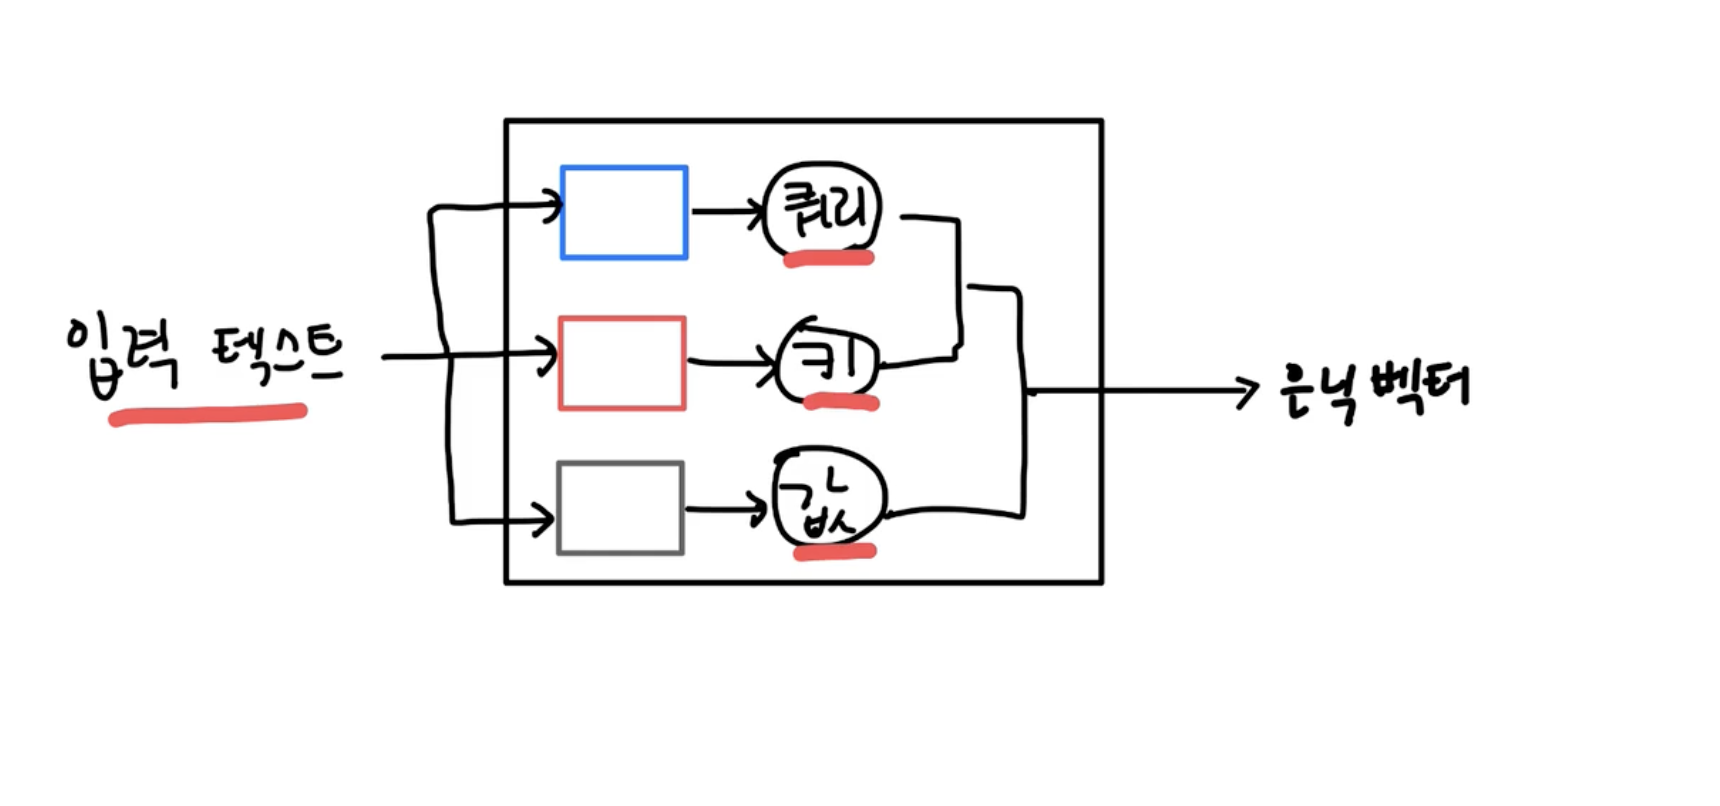

트랜스포머에서는 인코더에 입력되는 토큰만으로 어텐션 가중치를 학습하도록 만들었는데 이를 셀프 어텐션이라고 함.

입력 텍스트의 각 토큰을 같은 층에 있는 밀집층에 전체 토큰이 한 번에 통과한다. 그리고 통과될때도 바로 통과하는게 아니라 단어 임베딩 과정을 거친다.

밀집층을 통과한 벡터를 쿼리 벡터라고 한다. 또한 같은 입력 텍스트를 두 번째 밀집층에 통과 시켜 키 벡터를 만든다. 이러한 쿼리 생성 밀집층과 키 생성 밀집층은 서로 다른 층이다.

쿼리 벡터와 키 벡터 생성 후 두 벡터를 곱해서 어텐션 점수를 계산한다.(입력 토큰이 3개면 쿼리 벡터도 3개, 키벡터도 3개이므로 9개의 어텐션 점수가 만들어지고 이를 행렬 형태로 정리한 것이 어텐션 행렬)

그 다음 입력 텍스트를 또 다른 밀집층에 통과시켜 값 벡터를 만든다.

이제 계산된 어텐션 점수를 값 벡터에 곱해서 최종적인 셀프 어텐션 출력을 생성.

## 멀티 헤드 어텐션
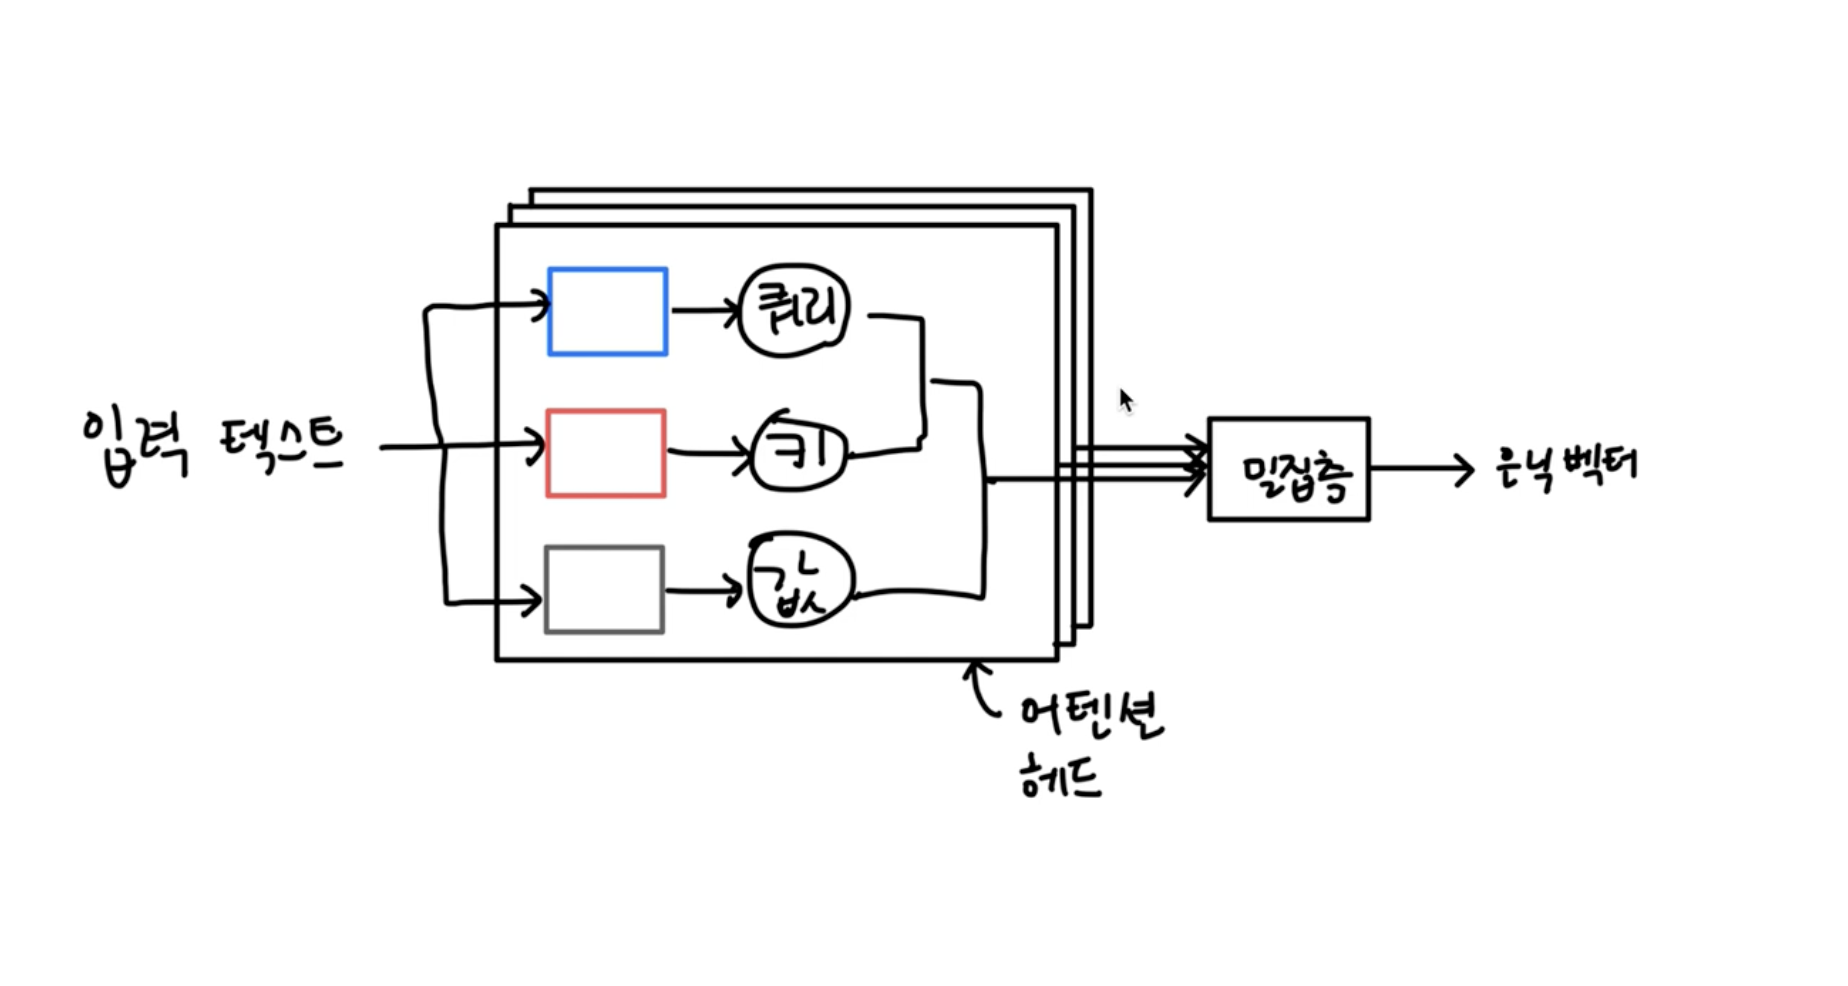

셀프 어텐션 연산을 수행하는 하나의 단위를 어텐션 헤드

트랜스포머는 여러개의 어텐션 헤드를 사용하는데 이를 멀티 헤드 어텐션 이라고 부른다.

어텐션 헤드들의 출력은 하나로 합쳐진 후, 밀집층을 통과하여 어텐션 층의 최종 출력이 된다.

입력 텍스트를 단어 임베딩을 하여 만든 입력 벡터의 개수가 마지막 은닉벡터의 개수랑 같다는 점 기억.

## 배치 정규화와 층 정규화
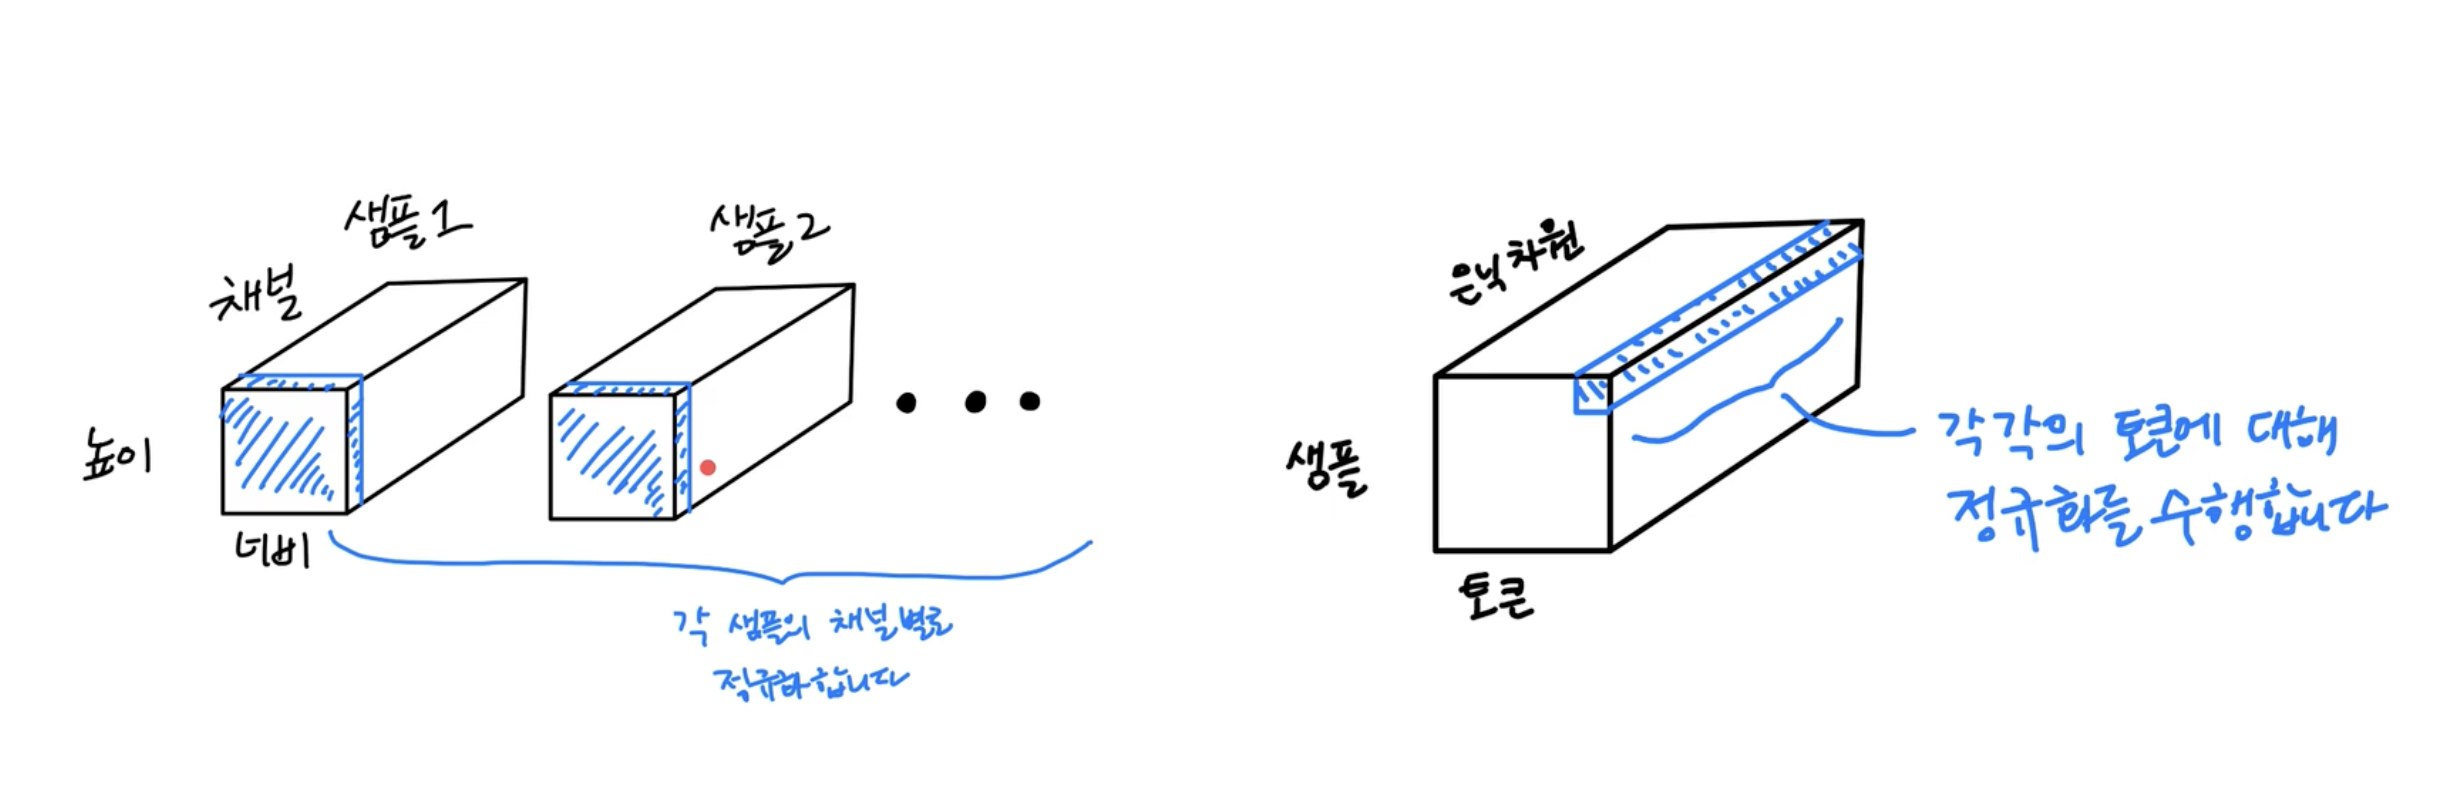

딥러닝에서는 여러 개의 층을 거치면서 특성의 스케일이 변할 수 있기에 단순 정규화가 맞지 않음. 이를 위해 고안된 것이 배치 정규화.

위 첫번째 그림처럼 정규화하면 텍스트 데이터는 샘플마다 길이가 다르기 때문에 적용이 어려웠다. 이를 위한 고안된 것이 층 정규화.

층 정규화는 각 샘플의 토큰마다 개별적으로 정규화 수행.

## 인코더의 어텐션 블록
지금까지 배운 멀티 헤드 어텐션과 드롭아웃, 층 정규화를 그림을 나타내면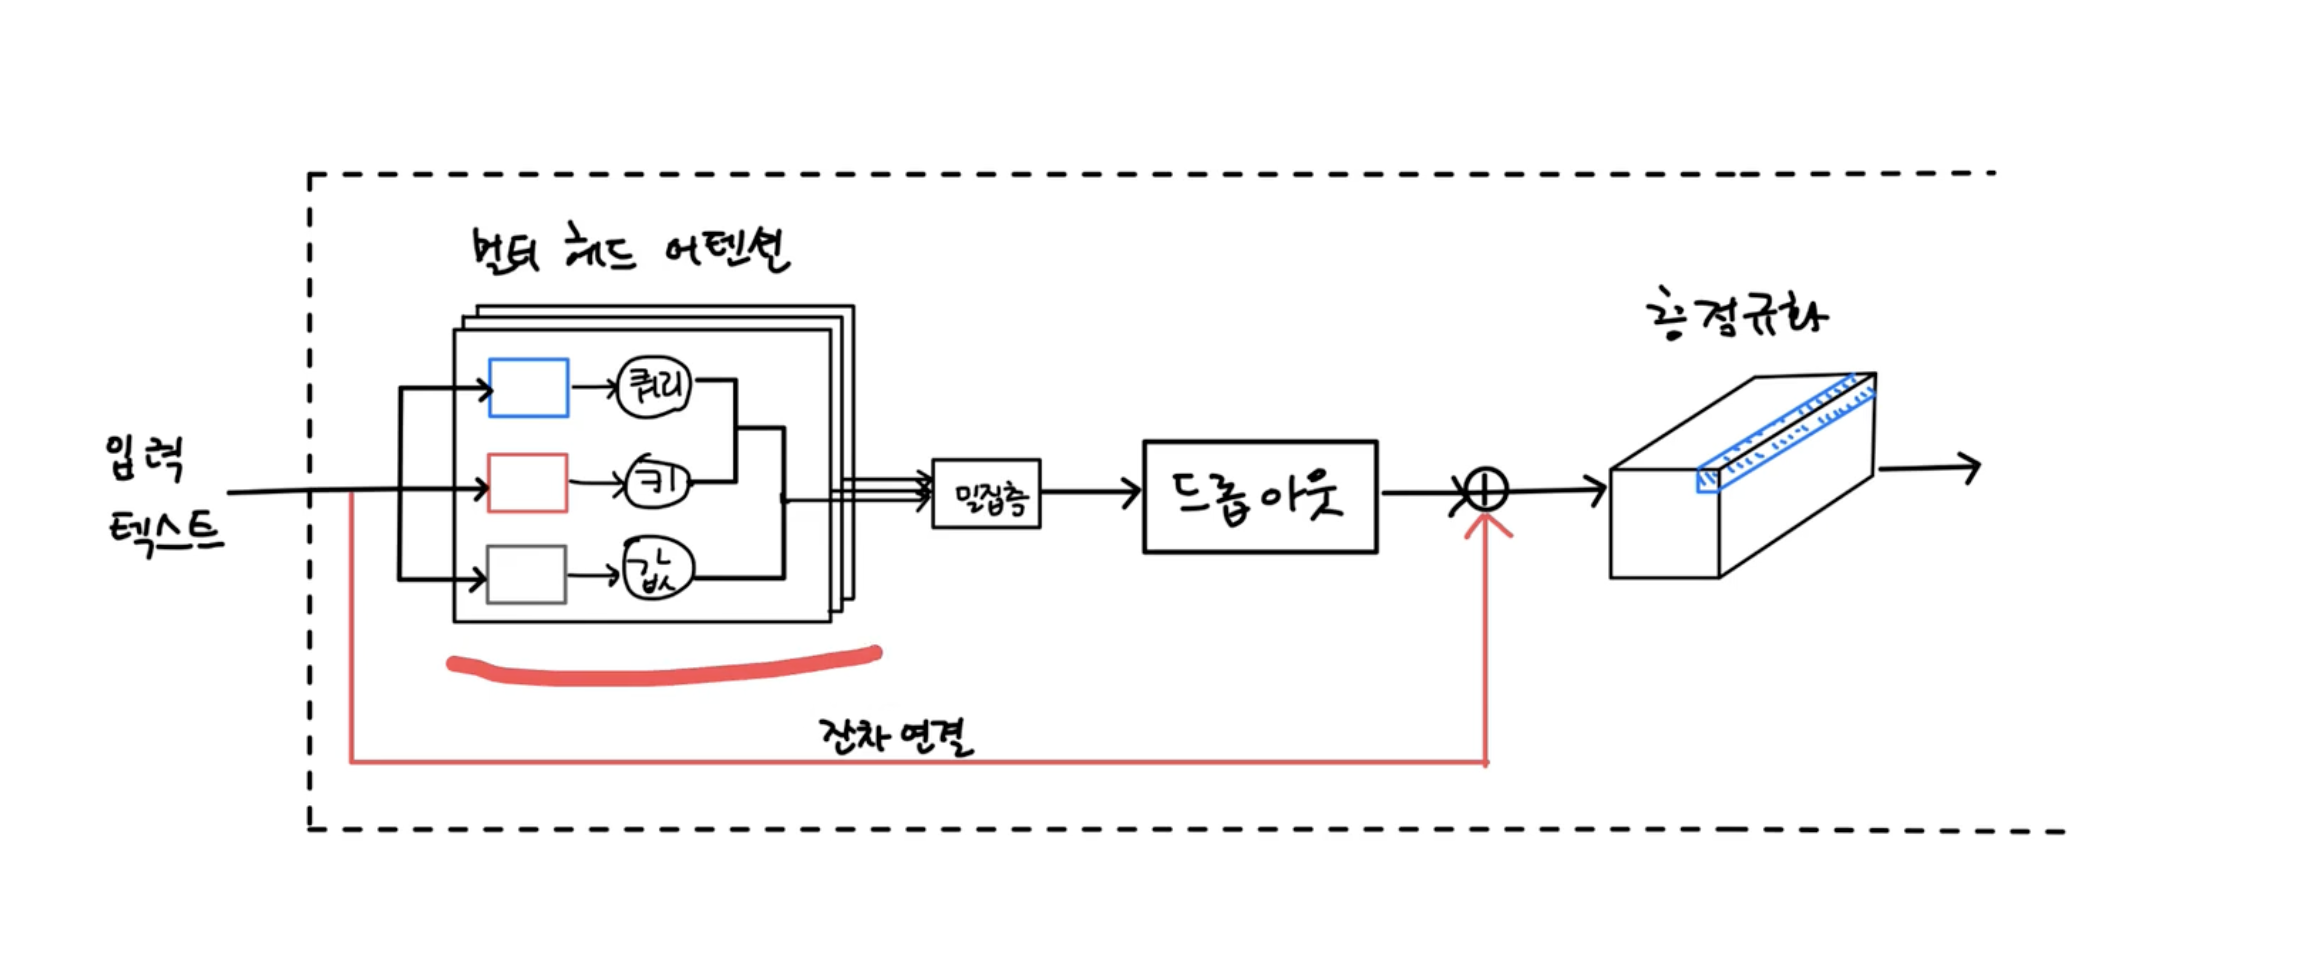

잔차 연결이 추가 되었는데 잔차 연결 또는 스킵 연결은 신경망 층이 많을수록 훈련이 어려워지기 때문에 도입.

멀티 헤드 어텐션 층을 거친 출력에 입력값을 그대로 더하는 방식이다.

## 피드 포워드 네트워크
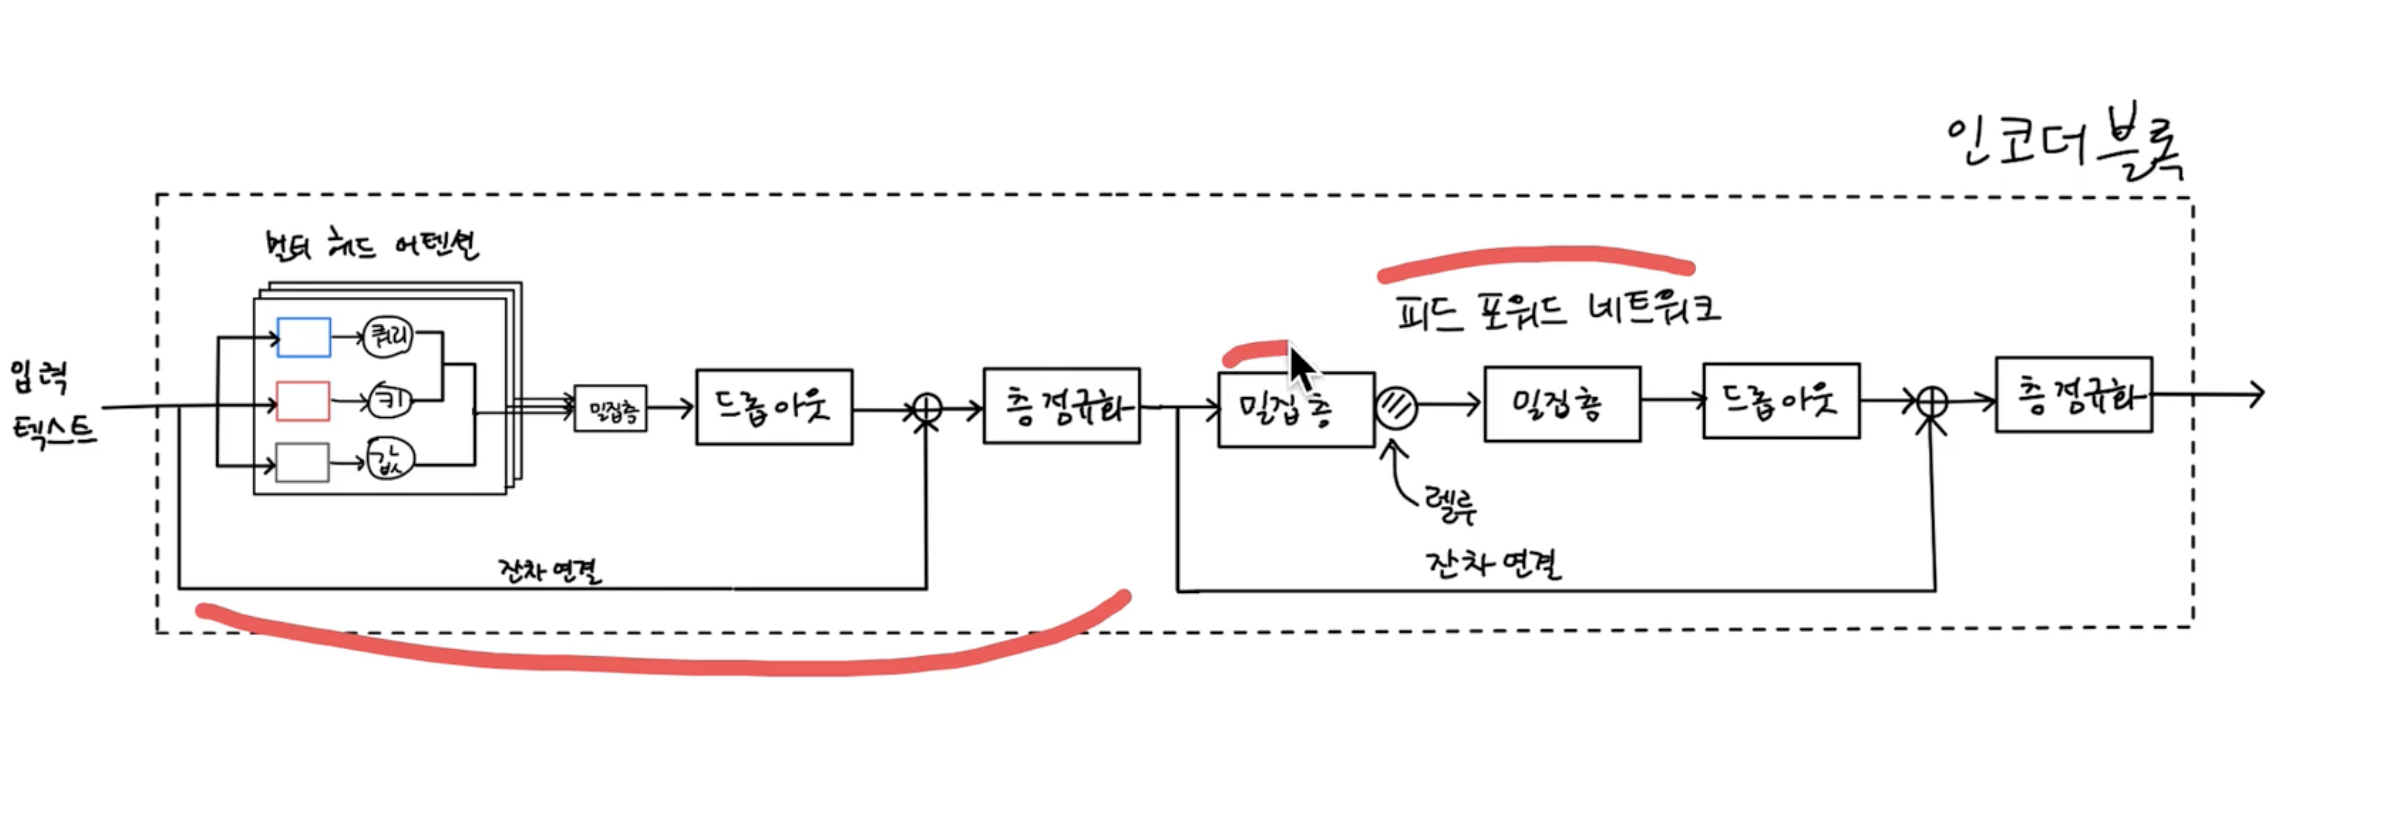

여기서 피드포워드 네트워크는 트랜스포머의 인코더에서 멀티 헤드 어텐션과 층 정규화 다음에 나오는 밀집층을 종종 피드포워드 네트워크라 부른다.

두개의 밀집층으로 구성되는데 첫번째 밀집층은 ReLU 활성화 함수를 사용하고 두번째 밀집층은 사용하지 않는다.

인코더 블록이 출력하는 값은 여전히 각 토큰의 은닉 벡터. 입력 토큰은 단어 임베딩과 같은 벡터 표현으로 변화되어 입력됨. 이런 특징 덕분에ㅡ 동일한 인코더 블록을 여러 개 반복해서 배치할 수 있다.

## 토큰 임베딩과 위치 임베딩
토큰 임베딩은 행렬의 계산 과정에서 토큰간의 관계는 반영되지만 위치는 따로 고려되지 않음.

하지만 단어는 그 위치에 따라 의미가 달라질 수 있다. 따라서 트랜스포머가 문장의 의미를 정확히 이해하려면 위치 정보가 추가적으로 제공되어야 한다. 이를 해결하기 위해 트랜스포머는 위치 인코딩을 사용한다.




## 디코더 블록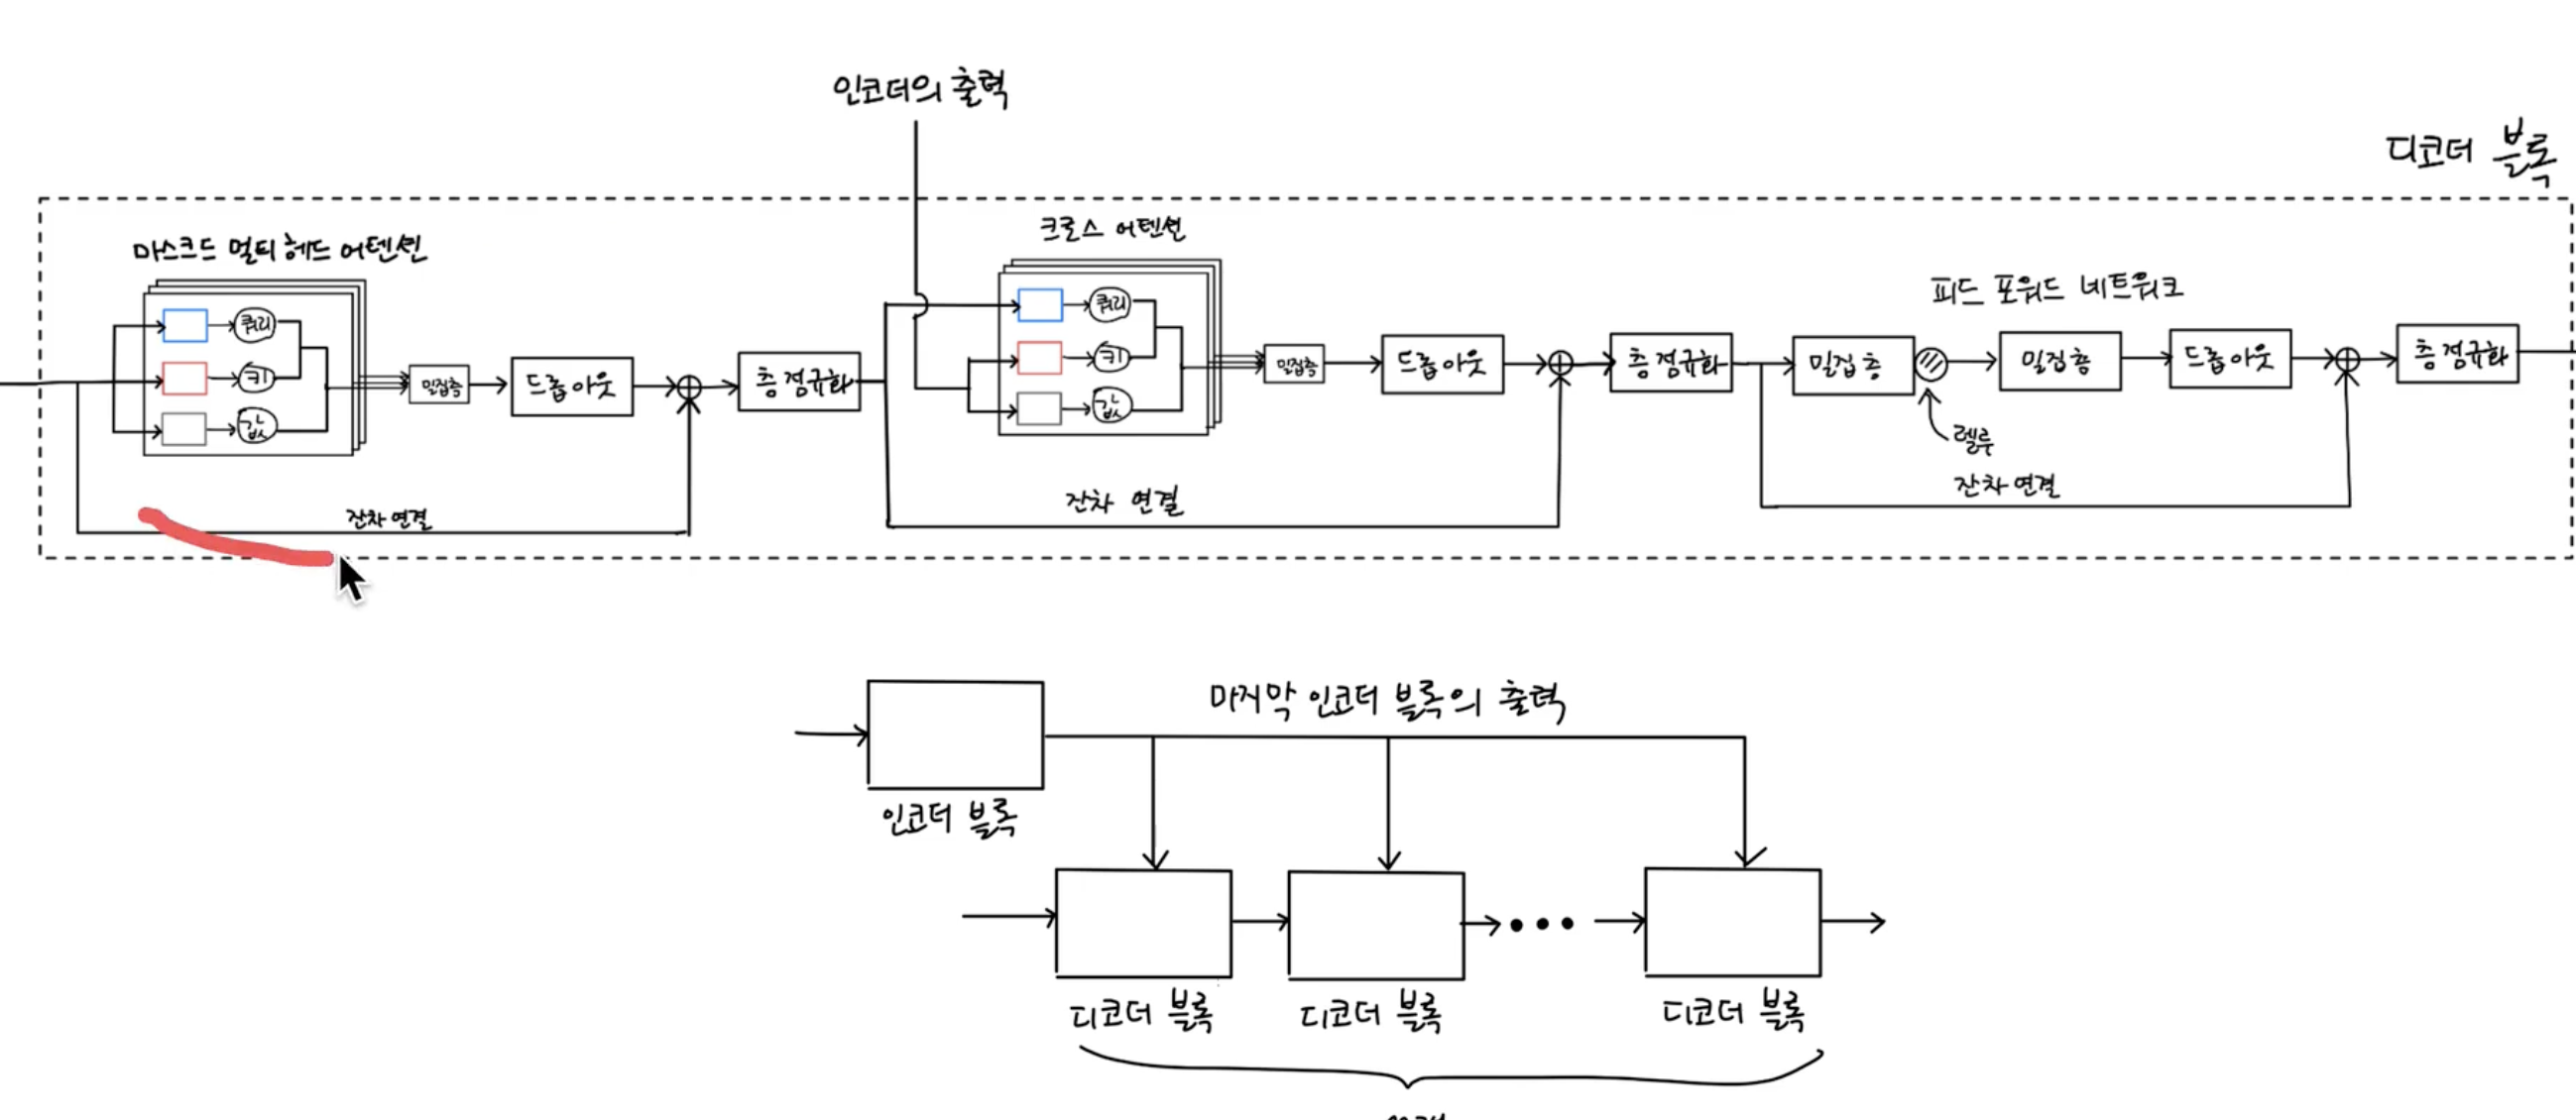


인코더와 다른점.

인코더가 출력한 임베딩 벡터를 입력으로 받는 멀티 헤드 어텐션 층. 이 층은 디코더에서 받은 벡터를 쿼리로 사용하고 인코더의 출력을 키와 값으로 사용. 그래서 크로스 언텐션이라고 부른다.

인코더 블록의 출력은 첫 번째 디코더 블록뿐만 아니라 반복되는 모든 디코더 블록에 전달됨.

디코더가 다음에 출력할 정답을 미리 알게 되면 올바른 학습이 이루어질수 없음.

따라사ㅓ 마스킹 처리를 하는데 디코더가 한 타임스텝에서 어텐션 점수를 계산할 때 현재 토큰까지만 참고하고, 이후의 토큰은 볼수 없도록 제한한다. 마스크드 멀티헤드 어텐션층이라고 부른다.